In [88]:
%config InlineBackend.rc = {"font.size": 12, "axes.titlesize": 14}
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp,odeint,quad,cumulative_trapezoid
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import linregress
from IPython.display import display, Math, Markdown

## Initialisation

In [89]:
V_chauf = 12 # 14.4
# t = [0,10,20,30,40,50,60,70,80,90,100]
t_chauf = np.linspace(0,430,44)
# r_meassuree = [45,40,36,32.30,28,24.56,22.6,20.80,19.30,18.30,17.40]
r_chauf = [52,49,42.8,38.9,34.8,31.7,29.0,27,25.4,24,22.8,22,21.3,20.5,19.7,19.7,
              19.1,18.8,18.5,18.3,18,17.8,17.6,17.5,17.4,17.3,17.2,17,16.8,16.7,16.6,
              16.6,16.6,16.5,16.5,16.5,16.4,16.3,16.4,16.3,16.2,16.2,16.2,16.2]
r_chauf = [1000 * x for x in r_chauf]
# i_entree = [1,0.8,0.72,0.60,0.5,0.48,0.43,0.39,0.35,0.33,0.31]
i_chauf = [0.90,0.8,0.7,0.66,0.60,0.54,0.50,0.46,0.42,0.40,0.38,0.36,0.34,0.33,0.32,
           0.32,0.29,0.28,0.28,0.27,0.27,0.26,0.26,0.25,0.25,0.25,0.24,0.24,0.24,0.23,0.23,
           0.23,0.24,0.23,0.23,0.23,0.23,0.23,0.23,0.23,0.23,0.23,0.23,0.23]
## Refroidisement
r_reff = [15.40,15.70,16.70,17.89,18.88,22.2,24.2,25.3,26.6,27.8,29.1,30,30.9,31.7,32.9,33.8,34.8,
         35.5,36.4,36.4]
r_reff = [1000 * x for x in r_reff]
t_reff = np.linspace(0,380,20)

In [90]:
Kelvin_Offset = 273.15
T0 = 25.0 + Kelvin_Offset
Ta = 22.0 + Kelvin_Offset
beta = 4450.0
R0 = 47000.0
T_chauf = []
P_chauf = []
T_reff = []

for idx,r in enumerate(r_chauf):
    T_chauf.append(1/((1/T0)+((1/beta)*np.log(r/R0))))
    P_chauf.append(V_chauf*i_chauf[idx])
    
for idx,r in enumerate(r_reff):
    T_reff.append(1/((1/T0)+((1/beta)*np.log(r/R0))))

## Graphiques de comportement pendant le chauffage et le refroidissement

Text(0.5, 1.0, 'Temperature vs t (chauffage)')

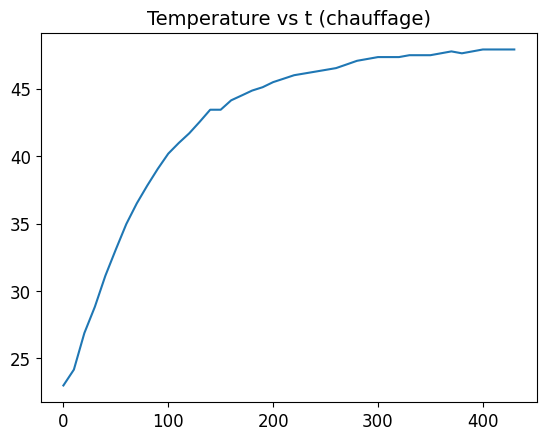

In [91]:
plt.plot(t_chauf,T_chauf-273.15*np.ones(44))
plt.title("Temperature vs t (chauffage)")

Text(0.5, 1.0, 'Puissance vs t (chauffage)')

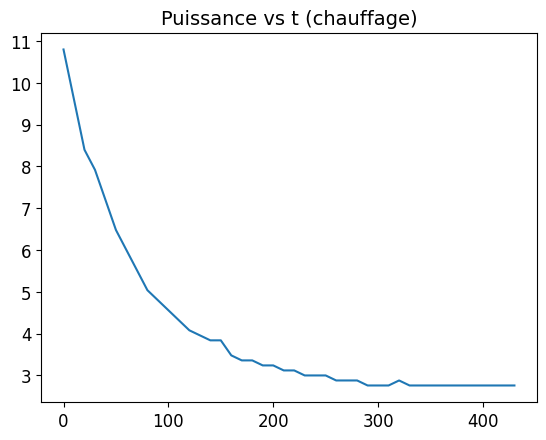

In [92]:
plt.plot(t_chauf,P_chauf)
plt.title("Puissance vs t (chauffage)")

Text(0.5, 1.0, 'Temperature vs t (refroidisemment)')

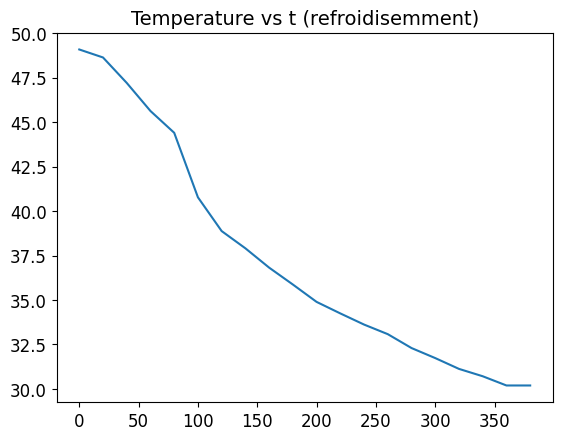

In [93]:
plt.plot(t_reff,T_reff-273.15*np.ones(20))
plt.title("Temperature vs t (refroidisemment)")

## Obtention de $\tau$ pendant le refroidissement
Pendant le refroidissement, l'équation de la chaleur est 
$$ a\cdot\frac{dT}{dt} + b\cdot T = b\cdot T_a $$ 
et la solution de cette équation est 
$$ T = (T_{max}-T_a)\cdot e^{-b\cdot t/a}  + T_a$$
- $a =  m\cdot C_p$
- $b = h_c\cdot S$
- $T_{max} = $température maximale atteinte pendant le chauffage
- $T_s = $ température ambiante

Le facteur $\frac{a}{b}$ est la constante de temps $\tau$, et en développant l'expression précédente on arrive à

$$
\Huge
\tau = \frac{t}{{\log\frac{T_{max}-T_a}{T-T_a}}}
$$
Les valeurs de $T$, $T_{max}$, $T_a$ sont connues pour chaque instant t, donc $\tau$ peut être calculé comme la moyenne de l'expression ci-dessus.

Tau = 360.61s


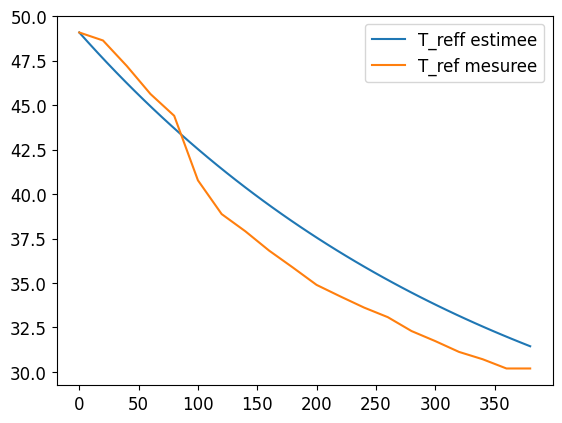

In [94]:
tau = (t_reff[1:]/np.log((T_reff[0]-Ta)/(np.array(T_reff[1:])-Ta))).mean()
t_sol = np.linspace(0.0,t_reff[-1],50)
T_solReff = np.array([])
for t in t_sol:
 T_solReff =  np.append(T_solReff,(T_reff[0]-Ta)*np.exp(-t/tau)+Ta) #Kelvin (T_reff[0]-295.15)*np.exp(-t/tau)+295.15
plt.plot(t_sol,T_solReff-273.15,label='T_reff estimee')
plt.plot(t_reff,np.array(T_reff)-273.15,label='T_ref mesuree')
plt.legend()
print(f'Tau = {tau:.2f}s')

### Interpolation sur les données pour avoir des courbes plus lisses

In [95]:
interpolateurT = interp1d(t_chauf, T_chauf, kind='cubic') #Interpolateur de température

aux = np.linspace(t_chauf.min(), t_chauf.max(), 1000) #vecteur de temps avec un dt plus petit
T_chauf = interpolateurT(aux) #Vecteur de température en fonction des interpolateurs

interpolateurP = interp1d(t_chauf, P_chauf, kind='cubic') #Interpolateur de puissance
P_chauf = interpolateurP(aux) #Vecteur de puissance en fonction des interpolateurs

interpolateurI = interp1d(t_chauf, i_chauf, kind='cubic') #Interpolateur de courant
i_chauf = interpolateurI(aux) #Vecteur de puissance en fonction des interpolateurs

t_chauf = aux

## Obtention d'une courbe de puissance

Compte tenu de la forme de la courbe de puissance pendant le chauffage, on tentera de la rapprocher d'une courbe exponentielle de la forme $P_0\cdot e^{(\frac{-t}{\tau_p})}+P_{offset}$, où le coefficient $\tau_p$ sera déterminé à partir des données expérimentales en calculant la valeur du temps pour laquelle la courbe de puissance diminue de $\approx63\%$

Pourcentage d'erreur maximal dans l'approximation de la puissance: 13.64%
P_mesuree = 8.8441*e^(-t/45.4818)+3.0545


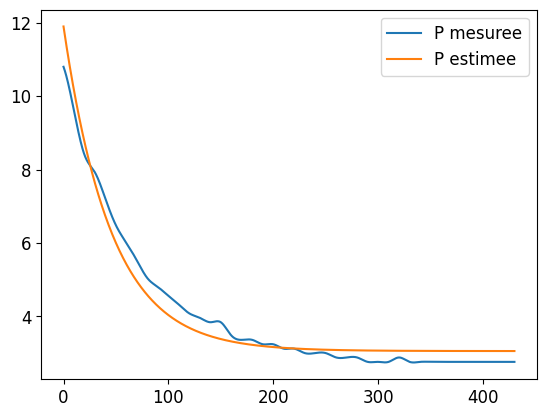

In [96]:
t1 = 0
for idx,t in enumerate(t_chauf):
    if P_chauf[idx] > (1-np.exp(-1))*P_chauf[0]:
        pass
    else:
        t1 = t
        P_063_approx = P_chauf[idx]
        break

tau_p = (P_chauf[0]*(1-np.exp(-1))-P_063_approx)*10+t1

def model_P(t,x,off):
    return x*np.exp(-t/tau_p)+off

popt,_ = curve_fit(model_P,t_chauf,P_chauf)
P_0,P_off = popt
P_ajustee = P_0*np.exp(-t_chauf/tau_p)+P_off
plt.plot(t_chauf,P_chauf,label='P mesuree')
plt.plot(t_chauf,P_ajustee,label='P estimee')
plt.legend()
P_err = max(abs(a-b) for a,b in zip(P_chauf,P_ajustee))*100/(max(P_chauf)-min(P_chauf))
print(f'Pourcentage d\'erreur maximal dans l\'approximation de la puissance: {P_err:.2f}%')
print(f'P_mesuree = {P_0:.4f}*e^(-t/{tau_p:.4f})+{P_off:.4f}')

## Obtention des paramètres a = m.Cp et b = hc.S

Lors du chauffage, la température tend vers 50°C, donc $\frac{\delta T}{t} = 0$, alors $a\cdot\frac{\delta T}{t} +b\cdot (T-T_a) = P_{entrant}$, en prenant la limite $\delta T \rightarrow 0$, on obtient $b =\frac{P_{entrant}}{T-T_a}$

In [97]:
b = P_chauf[-1]/(T_chauf[-1]-Ta)
a = tau*b
a,b

(38.40985865717474, 0.10651297407953049)

Les valeurs obtenues sont approximatives, elles peuvent donc être améliorées en ajustant une courbe de la forme a.T'+b.T à la courbe P, en fonction des valeurs mesurées de T et P.

In [98]:
T_derivee = np.gradient(T_chauf,t_chauf)

def model_T(t,a,b):
   return a*T_derivee + b*(T_chauf-Ta)

popt,_ = curve_fit(model_T,t_chauf,P_chauf,p0=[a,b])
a,b = popt
tau = a/b
a,b,tau

(31.078999494157205, 0.09847939440277365, 315.5888567617133)

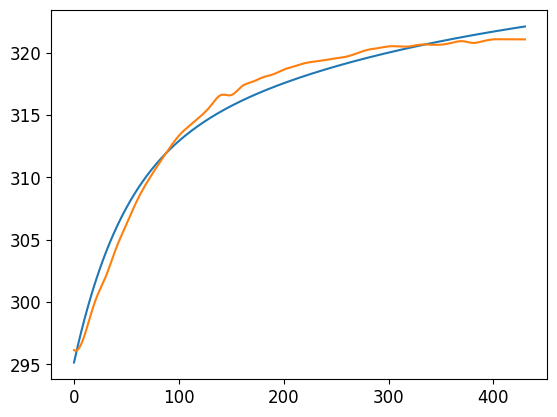

In [99]:
C = -((P_0/(b-(a/tau_p)))+(P_off/b))
T_ajustee = C*np.exp(-t_chauf/tau) + P_0*np.exp(-t_chauf/tau_p)/(b-(a/tau_p)) + Ta + P_off/b 
plt.plot(t_chauf,T_ajustee)
plt.plot(t_chauf,T_chauf)

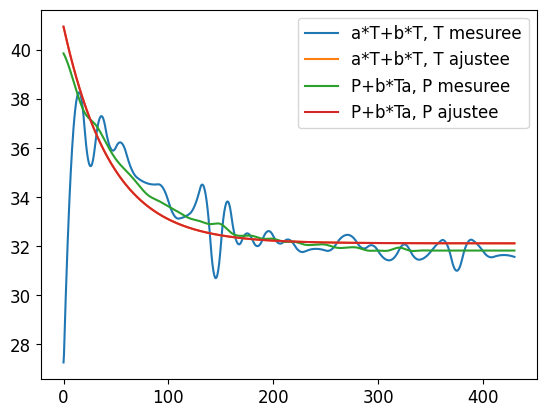

In [100]:
T_derivee = np.gradient(T_chauf,t_chauf)
T_ajus_derivee = np.gradient(T_ajustee,t_chauf) 
plt.plot(t_chauf,a*T_derivee+b*np.array(T_chauf),label='a*T+b*T, T mesuree')
plt.plot(t_chauf,a*T_ajus_derivee+b*T_ajustee,label='a*T+b*T, T ajustee')
plt.plot(t_chauf,P_chauf+b*Ta,label='P+b*Ta, P mesuree')
plt.plot(t_chauf,P_ajustee+b*Ta,label='P+b*Ta, P ajustee')
plt.legend()

In [101]:
edo_err = max(abs(a-b) for a,b in zip(a*T_ajus_derivee[1:]+b*T_ajustee[1:], P_ajustee[1:]+b*Ta))*100/(max(T_chauf)-min(T_chauf))
print(f'Pourcentage d\'erreur maximal dans l\'edo m.Cp.T\'+hc.S.(T-Ta) = P avec courbes P et T ajustées: {edo_err:.4f}%')

Pourcentage d'erreur maximal dans l'edo m.Cp.T'+hc.S.(T-Ta) = P avec courbes P et T ajustées: 0.0011%


In [102]:
T_err = max(abs(a-b) for a,b in zip(T_ajustee, T_chauf))*100/(max(T_chauf)-min(T_chauf))
print(f'Pourcentage d\'erreur maximum entre la courbe de température mesurée et ajustée: {T_err:.2f}%')

Pourcentage d'erreur maximum entre la courbe de température mesurée et ajustée: 7.70%


# Resultats

Avec les valeurs obtenues on peut dire que la température est représentée par l'équation
$$
T(t) = (\frac{P_{off}}{b}-\frac{P_0}{b-\frac{a}{\tau_p}})\cdot e^{-\frac{t}{\tau}} + \frac{P_0\cdot e^{-\frac{t}{\tau_p}}}{b-\frac{a}{\tau_p}} + Ta + \frac{P_{off}}{b}
$$

* Paramètres thermiques pour l'EDO  $ a\cdot\frac{dT}{dt} + b\cdot T = P(t) + b\cdot T_a$
  + $a = m\cdot C_p = 31.07\frac{W}{sK}$
  + $b = h_c\cdot S = 0.098\frac{W}{K} $
  + $\tau = \frac{a}{b} = 315.58 s$
* Paramètres de puissance pour la courbe $P(t)=P_0\cdot e^{(\frac{-t}{\tau_p})}+P_{offset}$
  + $\tau_p = 45.48 s$
  + $P_{off} = 3.05W$
  + $P_0 = 8.84W$
* $T_a = 22°C$ (Température ambiante)

## Température = f(Puissance) (Ce n'est pas encore fini)

Étant la résistance chauffante de type PTC, nous allons essayer d'approximer le comportement $R=f(T)$ à l'aide d'une courbe de la forme $R0\cdot e^{\alpha\cdot(T-T_0)}$

R(T) = 11.0883 * e^(0.0601*(T-295.15))


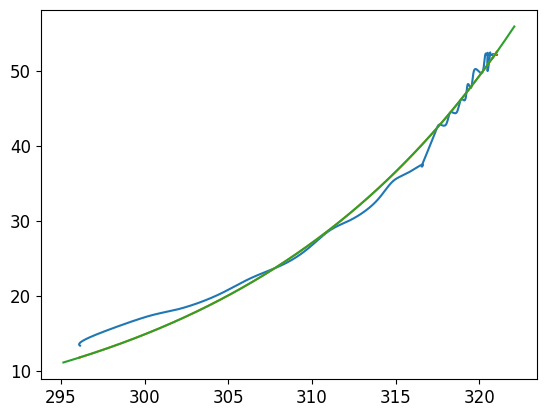

In [116]:
plt.plot(T_chauf,V_chauf/np.array(i_chauf))

def model_R(T,alpha,R0):
    return R0*np.exp(alpha*(T-Ta))

popt,_ = curve_fit(model_R,T_chauf,V_chauf/np.array(i_chauf))
alpha,R0 = popt
plt.plot(T_chauf,R0*np.exp(alpha*(T_chauf-Ta)))
plt.plot(T_ajustee,R0*np.exp(alpha*(T_ajustee-Ta)))
print(f'R(T) = {R0:.4f} * e^({alpha:.4f}*(T-{Ta}))')

0.12303472985501253

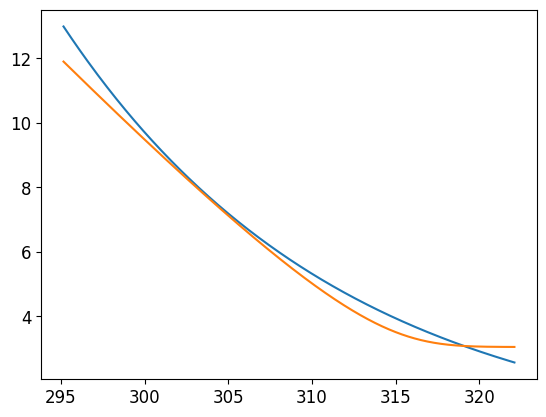

In [117]:
R_T = R0*np.exp(alpha*(T_ajustee-Ta))
plt.plot(T_ajustee,(V_chauf**2)/R_T)
plt.plot(T_ajustee,P_ajustee)
max(abs((V_chauf**2)/R_T-P_ajustee))/(max(P_ajustee)-min(P_ajustee))

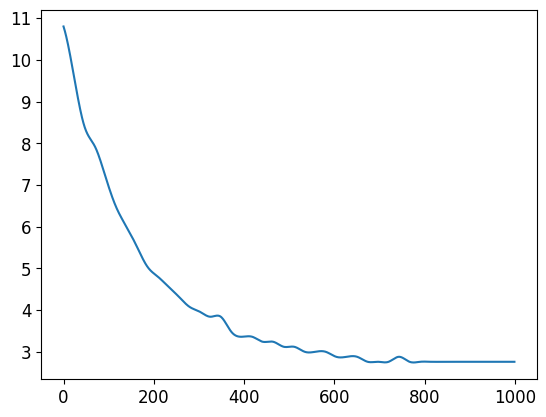

In [106]:
plt.plot(V_chauf*i_chauf)

In [119]:
R0_test = 11.0883
T0 = Ta
P_max = 15

def T_vs_P(V,Ta,Tf):
    T = Ta
    P = V**2/R0_test
    while T < Tf:

        if P >= P_max*0.92:
            raise ValueError("Puissance proche de la limite, température souhaitée non atteinte")

    return T

T=0
try:
    T = T_vs_P(0,0,0)
except Exception as e:
    print(e)
finally:
    print(f'T={T}')

T=0
